In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("S:/AI ML/Machine Learning/Datasets/height-weight.csv")

In [3]:
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


In [4]:
# Divide the dataset into independent nad dependent features

X = df[["Weight"]]  # Independent feature
y = df["Height"]  # Dependent feature

In [5]:
# Spliting Train and Test data
from sklearn.model_selection import train_test_split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [7]:
# Standardise the train independent data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [8]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# Train the model
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [10]:
lin_reg.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[17.03]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,157.5
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[4.24]


In [11]:
y_pred = lin_reg.predict(X_test_scaled)

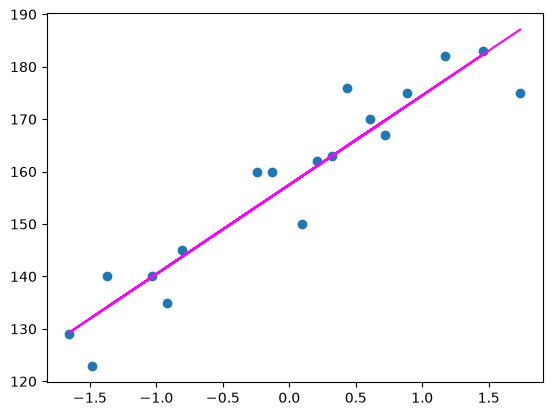

In [12]:
plt.scatter(X_train_scaled, y_train)
plt.plot(X_train_scaled, lin_reg.predict(X_train_scaled), "magenta")

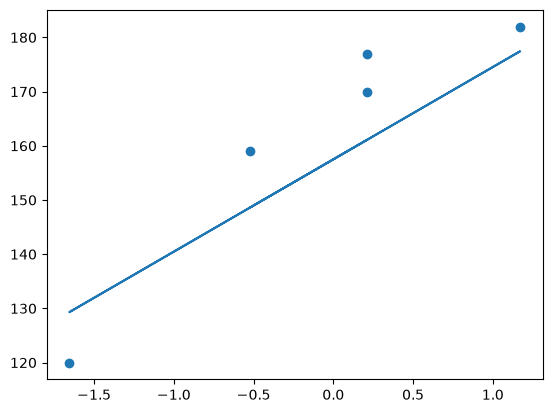

In [13]:
plt.scatter(X_test_scaled,y_test)
plt.plot(X_test_scaled,lin_reg.predict(X_test_scaled))

In [14]:
# Performance Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    root_mean_squared_error,
)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print("Mean Squared Error: ", mse)
print("Mean Absolute Error: ", mae)
print("Root Mean Squared Error: ", rmse)
print("R square: ", score)
print(
    "Adjusted R square: ",
    1 - (1 - score) * (len(y_test) - 1) / (len(y_test) - X_test_scaled.shape[1] - 1),
)

Mean Squared Error:  109.77592599051664
Mean Absolute Error:  9.822657814519232
Root Mean Squared Error:  10.477400726827081
R square:  0.776986986042344
Adjusted R square:  0.7026493147231252


In [15]:
# Testing model with new data
scaled_weight = scaler.transform([[45]])
lin_reg.predict([scaled_weight[0]])

C:\Users\Sarvadnya\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([129.3041561])

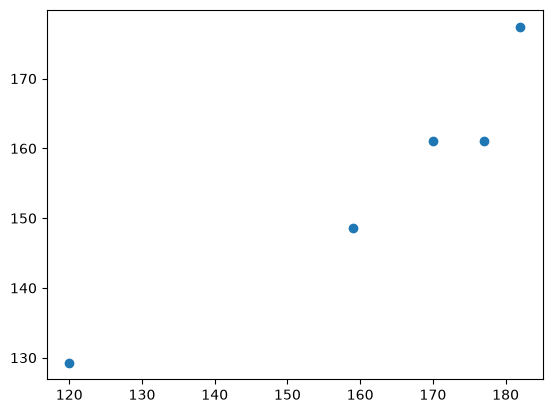

In [16]:
# Assumptions
plt.scatter(y_test,y_pred)

In [17]:
residuals = y_test - y_pred
residuals

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64

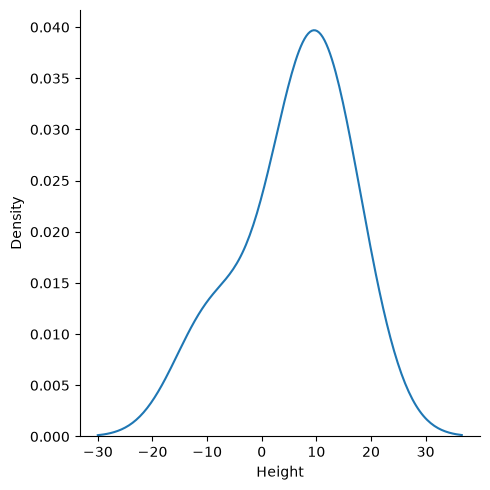

In [19]:
sns.displot(residuals,kind='kde')

<Axes: ylabel='Height'>

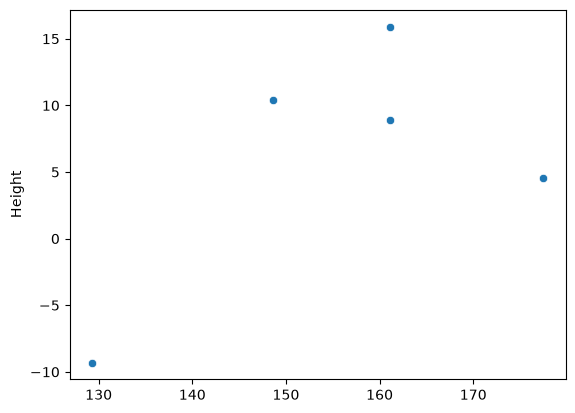

In [20]:
sns.scatterplot(x=y_pred,y=residuals)